1. Persiapan Lingkungan

In [1]:
!pip install -q split-folders

In [2]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders
import tarfile
import zipfile
from PIL import Image

from pathlib import Path
from PIL import Image
from google.colab import drive


import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetV2B0
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


2. Download dan Ekstraksi Dataset

In [3]:
drive.mount('/content/drive')

archive_path = '/content/drive/MyDrive/jagung/dataset_jagung.zip'
destination_path = '/content/dataset_jagung.zip'
extract_path = '/content/dataset'

if os.path.exists(archive_path):
    print("Moving ZIP file to /content...")
    shutil.copy(archive_path, destination_path)
    print("File successfully moved.")
else:
    print(f"Error: File not found at {archive_path}")

if os.path.exists(destination_path):
    if not os.path.exists(extract_path) or len(os.listdir(extract_path)) == 0:
        os.makedirs(extract_path, exist_ok=True)
        print("Extracting dataset...")
        try:
            with zipfile.ZipFile(destination_path, 'r') as zip_ref:
                zip_ref.extractall(path=extract_path)
            print("Extraction completed!")
        except Exception as e:
            print(f"Extraction failed: {e}")
    else:
        print("Dataset is already extracted and ready for use.")


Mounted at /content/drive
Moving ZIP file to /content...
File successfully moved.
Extracting dataset...
Extraction completed!


4. Data Cleaning dan Validasi Gambat (RGB)

In [4]:
dataset_path = "/content/dataset/dataset_jagung_v1"

def clean_image_data(directory):
    removed_count = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify()

                img = Image.open(file_path)
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                    img.save(file_path)
            except Exception as e:
                print(f"Removing corrupt/invalid file: {file_path}")
                os.remove(file_path)
                removed_count += 1
    return removed_count

print("Starting data cleanup process...")
removed = clean_image_data(dataset_path)
print(f"Cleanup completed. Total of {removed} problematic files removed.")


Starting data cleanup process...
Cleanup completed. Total of 0 problematic files removed.


5. Data Spliting (70/15/15/)

In [5]:
output_dir = "/content/dataset_split"

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

print("Splitting dataset into Train, Validation, and Test...")
splitfolders.ratio(dataset_path, output=output_dir,
                   seed=42, ratio=(0.7, 0.15, 0.15),
                   group_prefix=None, move=False)
print("Dataset splitting completed.")

train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'val')
test_dir = os.path.join(output_dir, 'test')

Splitting dataset into Train, Validation, and Test...


Copying files: 7106 files [01:11, 99.29 files/s]  

Dataset splitting completed.


6. Data Loader dan Augmentasi

In [6]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, shuffle=True, batch_size=BATCH_SIZE, image_size=IMG_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, shuffle=True, batch_size=BATCH_SIZE, image_size=IMG_SIZE)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, shuffle=False, batch_size=BATCH_SIZE, image_size=IMG_SIZE)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class names: {class_names}")

def to_one_hot(image, label):
    return image, tf.one_hot(label, NUM_CLASSES)

train_ds = train_ds.map(to_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(to_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(to_one_hot, num_parallel_calls=tf.data.AUTOTUNE)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2)
], name="data_augmentation")


Found 4973 files belonging to 4 classes.
Found 1063 files belonging to 4 classes.
Found 1070 files belonging to 4 classes.
Number of classes: 4
Class names: ['Bercak Daun', 'Daun Sehat', 'Karat Daun', 'hawar daun']


7. Visualisasi Sample dan Hasil Augmentasi

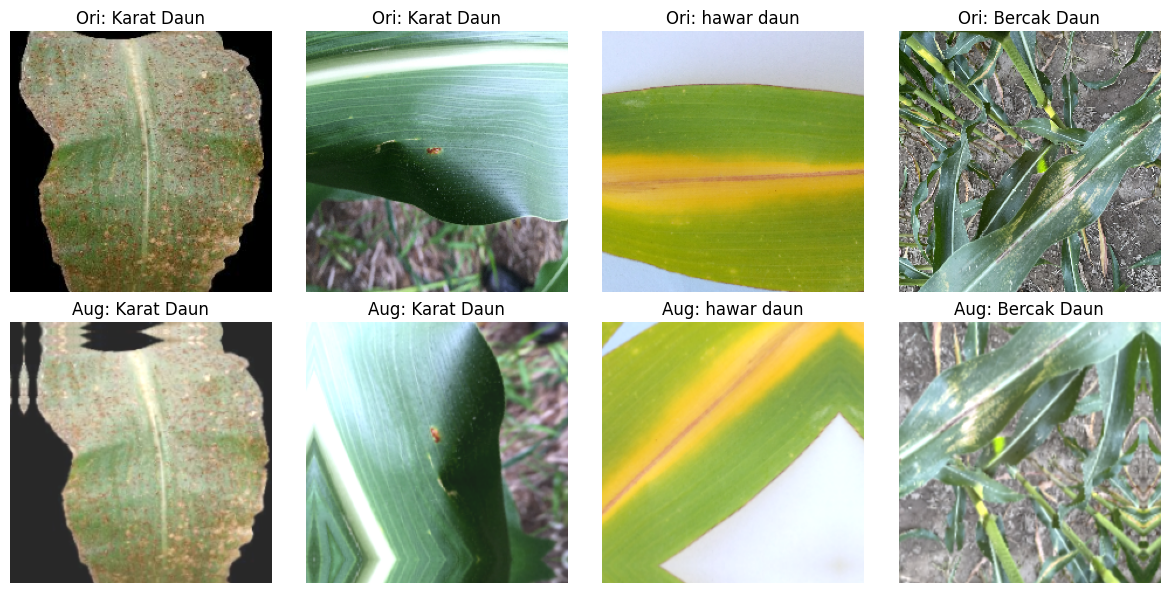

In [7]:
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(4):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        orig_class_idx = np.argmax(labels[i].numpy())

        plt.title(f"Ori: {class_names[orig_class_idx]}")
        plt.axis("off")

    augmented_images = data_augmentation(images, training=True)
    for i in range(4):
        ax = plt.subplot(2, 4, i + 5)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        orig_class_idx = np.argmax(labels[i].numpy())

        plt.title(f"Aug: {class_names[orig_class_idx]}")
        plt.axis("off")
plt.tight_layout()
plt.show()

8. Arsitektur Model CNN (EfficientNetv2B0)

In [8]:
def build_model(num_classes):
    base_model = EfficientNetV2B0(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights='imagenet',
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))

    x = data_augmentation(inputs)
    x = base_model(x, training=False)

    x = layers.Conv2D(512, (3, 3), padding='same', activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(256, (3, 3), padding='same', activation='swish')(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(1024, activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation='sigmoid', dtype='float32')(x)

    model = models.Model(inputs, outputs)
    return model, base_model

checkpoint_path = '/content/best_model/best_model.keras'

if os.path.exists(checkpoint_path):
    print(f"Loading weights from model checkpoint: {checkpoint_path}...")
    try:
        model = models.load_model(checkpoint_path)
    except Exception as e:
        print(f"Failed to load checkpoint model: {e}.")
        model, base_model = build_model(NUM_CLASSES)
else:
    print("No checkpoint found.")
    model, base_model = build_model(NUM_CLASSES)

model.summary()


No checkpoint found.
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 512)      │     5,898,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 256)      │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 3, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,272,404 (50.63 MB)

 Trainable params: 7,349,508 (28.04 MB)

 Non-trainable params: 5,922,896 (22.59 MB)

9. Implementasi Callbacks

In [9]:
checkpoint_cb = callbacks.ModelCheckpoint(
    "best_model/best_model.keras",
    save_best_only=True,
    monitor="val_loss",
    mode="min"
)

early_stopping_cb = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    mode="min"
)

reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1,
    mode="min"
)

callbacks_list = [checkpoint_cb, early_stopping_cb, reduce_lr_cb]


10. Training Model

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy')]
)

print("Training...")
EPOCHS_PHASE_1 = 15

history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE_1,
    callbacks=callbacks_list
)

Training...
Epoch 1/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.9153 - loss: 0.2220 - val_accuracy: 0.9459 - val_loss: 0.1425 - learning_rate: 0.0010
Epoch 2/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.9512 - loss: 0.1323 - val_accuracy: 0.9781 - val_loss: 0.0640 - learning_rate: 0.0010
Epoch 3/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.9649 - loss: 0.0948 - val_accuracy: 0.9730 - val_loss: 0.0645 - learning_rate: 0.0010
Epoch 4/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.9707 - loss: 0.0796 - val_accuracy: 0.9748 - val_loss: 0.0763 - learning_rate: 0.0010
Epoch 5/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - accuracy: 0.9725 - loss: 0.0770
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
156/156 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.9733 - loss: 0.0757 - val_accuracy: 0.9661 - val_loss: 0.0838 - learning_rate: 0.0010
Epoch 6/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.97

11. Plot History

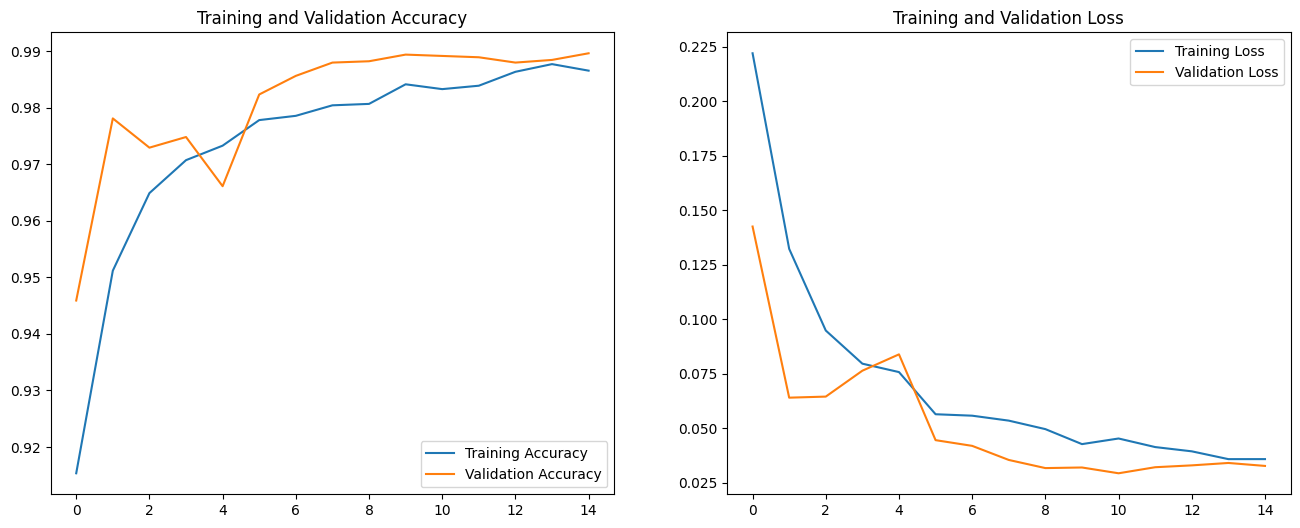

In [11]:
def plot_history(history_1, initial_epochs):
    acc = history_1.history['accuracy']
    val_acc = history_1.history['val_accuracy']
    loss = history_1.history['loss']
    val_loss = history_1.history['val_loss']

    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_history(history_1, EPOCHS_PHASE_1)

12. Test Time Augmentation

In [12]:
print("Evaluating model using TTA (Test-Time Augmentation) for Multi-Label...")

test_images = []
test_labels_true = []

for images, labels in test_ds.unbatch():
    test_images.append(images.numpy())
    test_labels_true.append(labels.numpy())

test_images = np.array(test_images)
test_labels_true = np.array(test_labels_true)

TTA_STEPS = 5
tta_predictions = []

for i in range(TTA_STEPS):
    print(f"TTA Step {i+1}/{TTA_STEPS}")
    aug_images = data_augmentation(test_images, training=True)
    preds = model.predict(aug_images, batch_size=BATCH_SIZE, verbose=0)
    tta_predictions.append(preds)

mean_tta_preds = np.mean(tta_predictions, axis=0)

THRESHOLD = 0.5
test_preds_binary = (mean_tta_preds > THRESHOLD).astype(int)

correct_predictions = np.equal(test_preds_binary, test_labels_true.astype(int))
tta_accuracy = np.mean(correct_predictions)

print(f"\nSubset Accuracy (Exact Match) on Test Set (with TTA): {np.mean(np.all(correct_predictions, axis=1)) * 100:.2f}%")
print(f"Binary Accuracy (Per-Class Average) on Test Set (with TTA): {tta_accuracy * 100:.2f}%")


Evaluating model using TTA (Test-Time Augmentation) for Multi-Label...
TTA Step 1/5
TTA Step 2/5
TTA Step 3/5
TTA Step 4/5
TTA Step 5/5

Subset Accuracy (Exact Match) on Test Set (with TTA): 97.20%
Binary Accuracy (Per-Class Average) on Test Set (with TTA): 98.86%


13. Metrik Evaluasi


Classification Report (Multi-Label):

              precision    recall  f1-score   support

 Bercak Daun       0.96      0.94      0.95       224
  Daun Sehat       0.99      1.00      1.00       345
  Karat Daun       0.97      0.98      0.98       259
  hawar daun       0.98      0.97      0.98       242

   micro avg       0.98      0.98      0.98      1070
   macro avg       0.98      0.97      0.97      1070
weighted avg       0.98      0.98      0.98      1070
 samples avg       0.97      0.98      0.98      1070



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


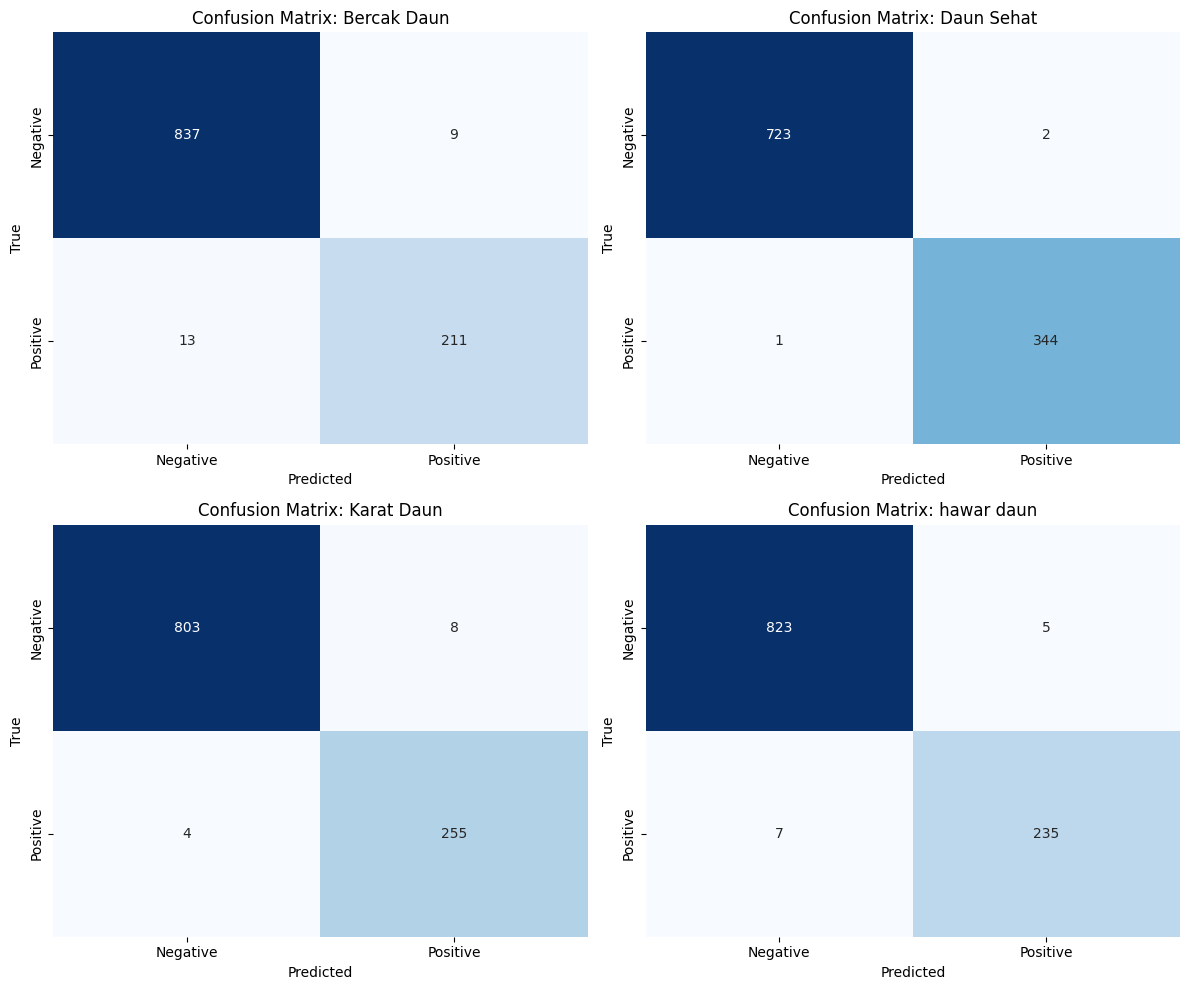

In [13]:
from sklearn.metrics import multilabel_confusion_matrix

print("\nClassification Report (Multi-Label):\n")
print(classification_report(test_labels_true, test_preds_binary, target_names=class_names))

mcm = multilabel_confusion_matrix(test_labels_true, test_preds_binary)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, class_name in enumerate(class_names):
    sns.heatmap(mcm[i], annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    axes[i].set_title(f'Confusion Matrix: {class_name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.tight_layout()
plt.show()